In [413]:
import signal_gen_toolbox as sgt

import importlib
importlib.reload(sgt)

fn_yaml = "config.yaml"

N_loadcases = 5


In [414]:
config = sgt.load_config(fn_yaml)

{'signals': {'sig1': {'display_name': 'signal_1',
                      'units': 'F',
                      'parameters': {'magnitude': {'distribution_type': 'uniform',
                                                   'min_value': 0,
                                                   'max_value': 100},
                                     'rate_of_change': {'distribution_type': 'uniform',
                                                        'min_value': -10,
                                                        'max_value': 10,
                                                        'set_to_0_probability': 0.3}},
                      'plot_color': 'red'},
             'sig2': {'display_name': 'signal_2',
                      'units': 'F',
                      'parameters': {'magnitude': {'distribution_type': 'uniform',
                                                   'min_value': 0,
                                                   'max_value': 200},
                      

In [415]:
samples = sgt.generate_samples(config, N = N_loadcases)
samples

{'sig1': {'magnitude': array([ 75.,   0.,  50., 100.,  25.]),
  'rate_of_change': array([  5., -10.,  10.,   0.,  -5.]),
  'ramp_start_time': array([ 5.5 ,  1.  ,  7.75,  3.25, 10.  ]),
  'ramp_duration': array([50. , 12.5, 25. ,  0. , 37.5]),
  'hold_duration': array([50. ,  0. , 37.5, 25. , 12.5]),
  'end_time': array([200., 200., 200., 200., 200.])},
 'sig2': {'magnitude': array([ 50., 100.,   0., 150., 200.]),
  'rate_of_change': array([  5., -10.,   0.,  -5.,  10.]),
  'ramp_start_time': array([ 3.25, 10.  ,  7.75,  5.5 ,  1.  ]),
  'ramp_duration': array([25. , 37.5, 50. , 12.5,  0. ]),
  'hold_duration': array([50. , 12.5,  0. , 25. , 37.5]),
  'end_time': array([200., 200., 200., 200., 200.])},
 'sig3': {'magnitude': array([  0., 300.,  75., 150., 225.]),
  'rate_of_change': array([ 100.,  -50.,   50.,    0., -100.]),
  'ramp_start_time': array([ 7.75,  3.25, 10.  ,  5.5 ,  1.  ]),
  'ramp_duration': array([ 0. , 25. , 37.5, 12.5, 50. ]),
  'hold_duration': array([50. , 37.5,  

In [416]:
idx = 0

df_signals, df_parameters = sgt.generate_ramp_signals(samples, config, idx)

print(df_signals)
print(df_parameters)



          sig1    sig2  sig3   sig4    sig5
t                                          
0.00     75.00   50.00   0.0  25.00   75.00
3.25     75.00   50.00   0.0  25.00   75.00
5.50     75.00   61.25   0.0  13.75   75.00
7.75     86.25   72.50   0.0  13.75   86.25
10.50   100.00   86.25   0.0  13.75  100.00
28.25   100.00  175.00   0.0  75.00  175.00
55.50   100.00  175.00   0.0  75.00  175.00
57.75   100.00  175.00   0.0  75.00  175.00
78.25   100.00  175.00   0.0  75.00  175.00
103.25  100.00   50.00   0.0  50.00  100.00
105.50  100.00   50.00   0.0  50.00  100.00
150.50  100.00   50.00   0.0  50.00  100.00
155.50   75.00   50.00   0.0  25.00   75.00
200.00   75.00   50.00   0.0  25.00   75.00
      initial_value  ramp_start_time  ramp_duration  effective_ramp_duration  \
sig1           75.0             5.50           50.0                      5.0   
sig2           50.0             3.25           25.0                     25.0   
sig3            0.0             7.75            0.0     

In [417]:


import pandas as pd

df_all = pd.DataFrame(index = range(N_loadcases), columns = ['loadcase_name', 'df_signals', 'df_parameters'])

for i in range(N_loadcases):
    loadcase_name = f"ramp_{i+1:05d}"
    df_signals, df_parameters = sgt.generate_ramp_signals(samples, config, i)
    df_all.loc[i,  ['loadcase_name', 'df_signals', 'df_parameters']] = [loadcase_name, df_signals, df_parameters]

print(df_all.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   loadcase_name  5 non-null      object
 1   df_signals     5 non-null      object
 2   df_parameters  5 non-null      object
dtypes: object(3)
memory usage: 252.0+ bytes
None


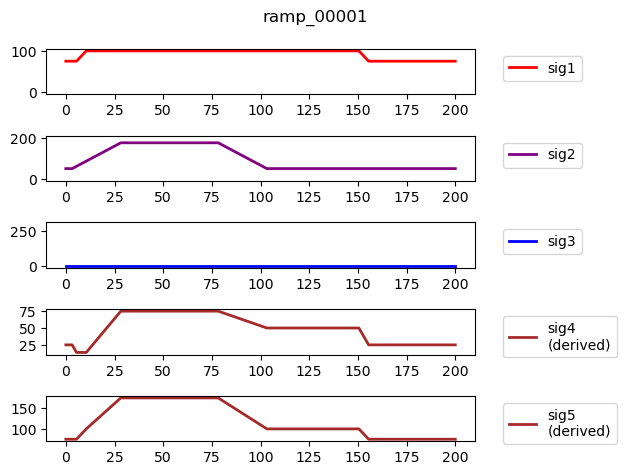

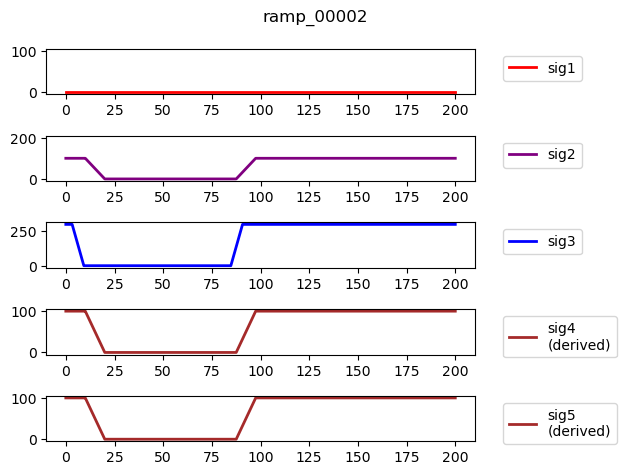

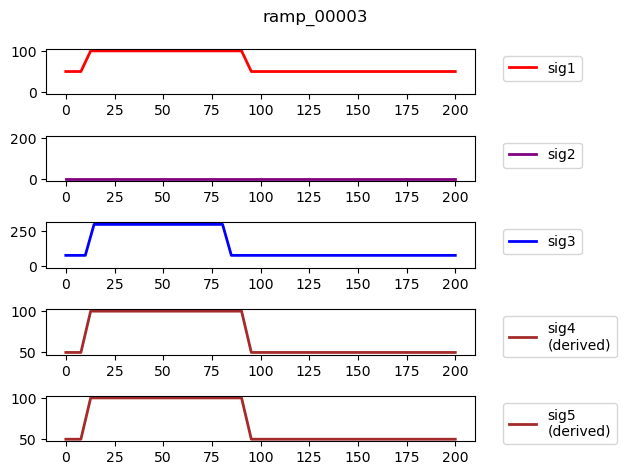

In [418]:
for i in range(3):
    loadcase_name = df_all.loc[i, 'loadcase_name']
    df_signals = df_all.loc[i, 'df_signals']
    sgt.plot_loadcase(df_signals, config, loadcase_name = loadcase_name)